# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

55.39999999999999 78.8


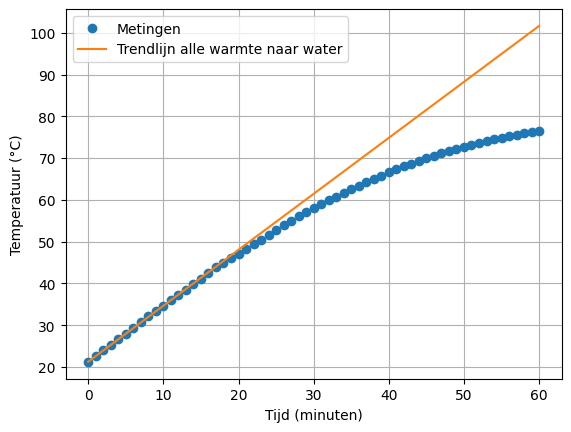

alle energie naar opwarming bad: 158811 J
-------------------------------------------
toegevoegde energie als het volledig naar het opwarmen en verdampen van water zou zijn gegaan.
bad verwarmen: 105257 J
verdamping: 5935 J
totaal: 111192 J
-------------------------------------------
het verschil tussen de twee waarden is 47619 J
er is dus 42.8% meer warmte verbruikt dan als alle warmte in de verdamping en opwarming van het bad had gezeten


In [48]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

tijd, temp = np.loadtxt('metingen_ishetverdamping.csv', delimiter=';', skiprows=1).T

# plt.plot(tijd, temp)
# plt.xlabel('Tijd (minuten)')
# plt.ylabel('Temperatuur (°C)')
# plt.grid()
# plt.show()

m_maatbeker = 0.8208  # kg
m_water_begin = 1.2929 - m_maatbeker  # kg
m_water_eind = 1.2749 - m_maatbeker  # kg
m_water_verdampt = m_water_begin - m_water_eind  # kg
c_water = 4184  # J/(kg·°C)
delta_temp = max(temp) - min(temp)
delta_temp_verdamp = 100 - min(temp)
print(delta_temp, delta_temp_verdamp)
totale_tijd = max(tijd)

# functiefitten
data_punten = 5
def lineair(t, a, b):
    return a * t + b
params, _ = curve_fit(lineair, tijd[:data_punten], temp[:data_punten])
a, b = params
helling = a # °C/min

# plot met fit eerste datapunten
t_fit = np.linspace(0, 60, 100)
plt.plot(tijd, temp, 'o', label='Metingen')
plt.plot(t_fit, lineair(t_fit, a, b), '-', label='Trendlijn alle warmte naar water')
plt.xlabel('Tijd (minuten)')
plt.ylabel('Temperatuur (°C)')
plt.legend()
plt.grid()
plt.show()

# ENERGIE TRENDLIJN
# hoeveel energie toegevoegd als alle warmte in het water zou zitten
energie_fit = helling * totale_tijd * c_water * m_water_begin
print(f"alle energie naar opwarming bad: {energie_fit:.0f} J")
# hierbij is aangenomen dat in het begin vrijwel alle warmte in het water bad gaat zitten.

print(43*"-")

# ENERGIE OPWARMING EN VERDAMPING WATER
# Totale energie: energie om water te laten verdampen + energie om water op te warmen naar eind temperatuur
print("toegevoegde energie als het volledig naar het opwarmen en verdampen van water zou zijn gegaan.")
# warmte die is toegevoegd aan het bad.
# kg * J/kg*°C * °C
warmte_naar_water = m_water_eind * c_water * delta_temp
print(f"bad verwarmen: {warmte_naar_water:.0f} J")

# warmte van verdampte water
warmte_naar_verdamping = m_water_verdampt * c_water * delta_temp_verdamp
# ik ga er van uit dat het verdampte water 100 °C is, in werkelijkheid kan dit verdampte water meer energie bevatten.
print(f"verdamping: {warmte_naar_verdamping:.0f} J")

# totaal energie toegevoegd
warmte_totaal = warmte_naar_water + warmte_naar_verdamping
# aangenomen dat al het verdwenen water uit de maatbeker verdampt is
print(f"totaal: {warmte_totaal:.0f} J")

print(43*"-")

# VERSCHIL
print(f"het verschil tussen de twee waarden is {energie_fit-warmte_totaal:.0f} J")
print(f"er is dus {(energie_fit-warmte_totaal)/warmte_totaal*100:.1f}% meer warmte verbruikt dan als alle warmte in de verdamping en opwarming van het bad had gezeten")


aanbevelingen voor een verbetering van het experiment:
- isoleer de maatbeker (beter) om warmteverlies te voorkomen
- neem de warmte die in de maatbeker gaat zitten ook mee in de berekening
- noteer het vermogen van het verwarmingselement zodat je niet de benadering van de eerste paar minuten hoeft te gebuiken 